In [1]:
import sys
sys.path.append("../ext/equi-rl-for-pomdps")
from rgbd_sym.api import make_env
import argparse
import numpy as np
from rgbd_sym.tool.plt import use_backend

from rgbd_sym.tool.sym import local_sym_step
from rgbd_sym.tool.depth import get_intrinsic_matrix, projection_matrix_to_K
import time
# use_backend('tkagg')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
sym_step_idx = 5
size = 84

args = {}

args['action_delta_pos'] = 0.05
args['action_delta_rot'] = np.pi / 8
args['pc_x_center'] = 0.0
args['pc_y_center'] = 0.0
args['pc_z_center'] = 0.75
args['pc_range'] = 0.8
args['voxel_res'] = 84
args['depth_real_min'] = 0
args['depth_real_max'] = 1
args['depth_upsample'] = 6
args['out_image_type'] = 'depth'
args['out_background_encoding'] = 255

In [33]:
from matplotlib.pyplot import imshow, subplot, axis, cm, show
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
%matplotlib inline


def plot_img(imgs_2d, big_axes_title=[],figsize=None):
    plt_cnt = 0
    row_size = np.max(np.array([len(k) for k in imgs_2d]))
    fig, big_axes = plt.subplots(nrows=len(imgs_2d), ncols=1, sharey=True)
    for row, big_ax in enumerate(big_axes, start=1):
        big_ax.set_title(big_axes_title[row-1], fontsize=16)

        # Turn off axis lines and ticks of the big subplot 
        # obs alpha is 0 in RGBA string!
        big_ax.tick_params(labelcolor=(1.,1.,1., 0.0), top='off', bottom='off', left='off', right='off')
        # removes the white frame
        big_ax._frameon = False
    for k, im in enumerate(imgs_2d):
        for i, img in enumerate(im):
            plt_cnt= row_size * k + i +1
            ax = subplot(len(imgs_2d), row_size, plt_cnt)
            if isinstance(img, dict):
                imshow(img['image'])
                if "title" in img:
                    plt.title(img['title'])
            else:
                imshow(img)
            plt.colorbar()
        # if i == (len(im) -1):
        #     ax.set_title(f"{titles[0]} step {i+1}, backtrace image!")
        # else:
        #     ax.set_title(f"{titles[k]} step {i+1}")
    # if not  no_show:
    show()


In [4]:
env, env_config = make_env(tags=['block_pull', "no_clutch"], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
print("K", K)
# generate ground truth trajectory
origin_actions = []
imgs1_meta = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    imgs1_meta.append(obs)
origin_depth_image_traj = []
for i in range(len(imgs1_meta)):
    origin_depth_image_traj.append(local_sym_step(imgs1_meta[i]['depth'],
                                                  imgs1_meta[i]['mask'], [],
                                                  K=K,
                                                  **args)[0])


# generate symmetric trajectry with backtrace
start_depth_dict = imgs1_meta[sym_step_idx]['depth']
start_mask_dict = imgs1_meta[sym_step_idx]['mask']
sym_actions = [a for a in origin_actions[:sym_step_idx]]
start = time.time()

sym_depth_image_traj = local_sym_step(
    start_depth_dict, 
    start_mask_dict, 
    sym_actions, 
    K=K, 
    reverse=True,
    **args)

print("local_sym_step() elspase time: ", time.time()- start)
sym_depth_image_traj.extend(origin_depth_image_traj[sym_step_idx+1:])
sym_actions.extend(origin_actions[sym_step_idx:])

sym_actions = [a for a in origin_actions[:sym_step_idx]]
sym_actions[0][1] = -1
sym_actions[1][1] = -1
sym_actions[2][1] = 1
sym_actions[3][1] = 1

sym_depth_image_traj2 = local_sym_step(
    start_depth_dict, 
    start_mask_dict, 
    sym_actions, 
    K=K, 
    reverse=True,
    **args)
sym_depth_image_traj2.extend(origin_depth_image_traj[sym_step_idx+1:])
sym_actions.extend(origin_actions[sym_step_idx:])

# ground truth env with sym actions
env, env_config = make_env(tags=['block_pull', "no_clutch"], seed=0)
origin_actions = []
obs = env.reset()
imgs2_meta = [obs]
for action in sym_actions:
    obs, reward, done, info = env.step(action)
    imgs2_meta.append(obs)
gt_env_traj_with_sym_actions = []
for i in range(len(imgs2_meta)):
    gt_env_traj_with_sym_actions.append(local_sym_step(imgs2_meta[i]['depth'],
                                                  imgs2_meta[i]['mask'], [],
                                                  K=K,
                                                  **args)[0])

pybullet build time: Nov 28 2023 23:52:03


robot id None
K [[59.98221231  0.         42.        ]
 [ 0.         59.98221231 42.        ]
 [ 0.          0.          1.        ]]


/home/ben/ssd/miniconda3/envs/rgbd-sym/lib/python3.9/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


local_sym_step() elspase time:  0.38524675369262695
robot id None


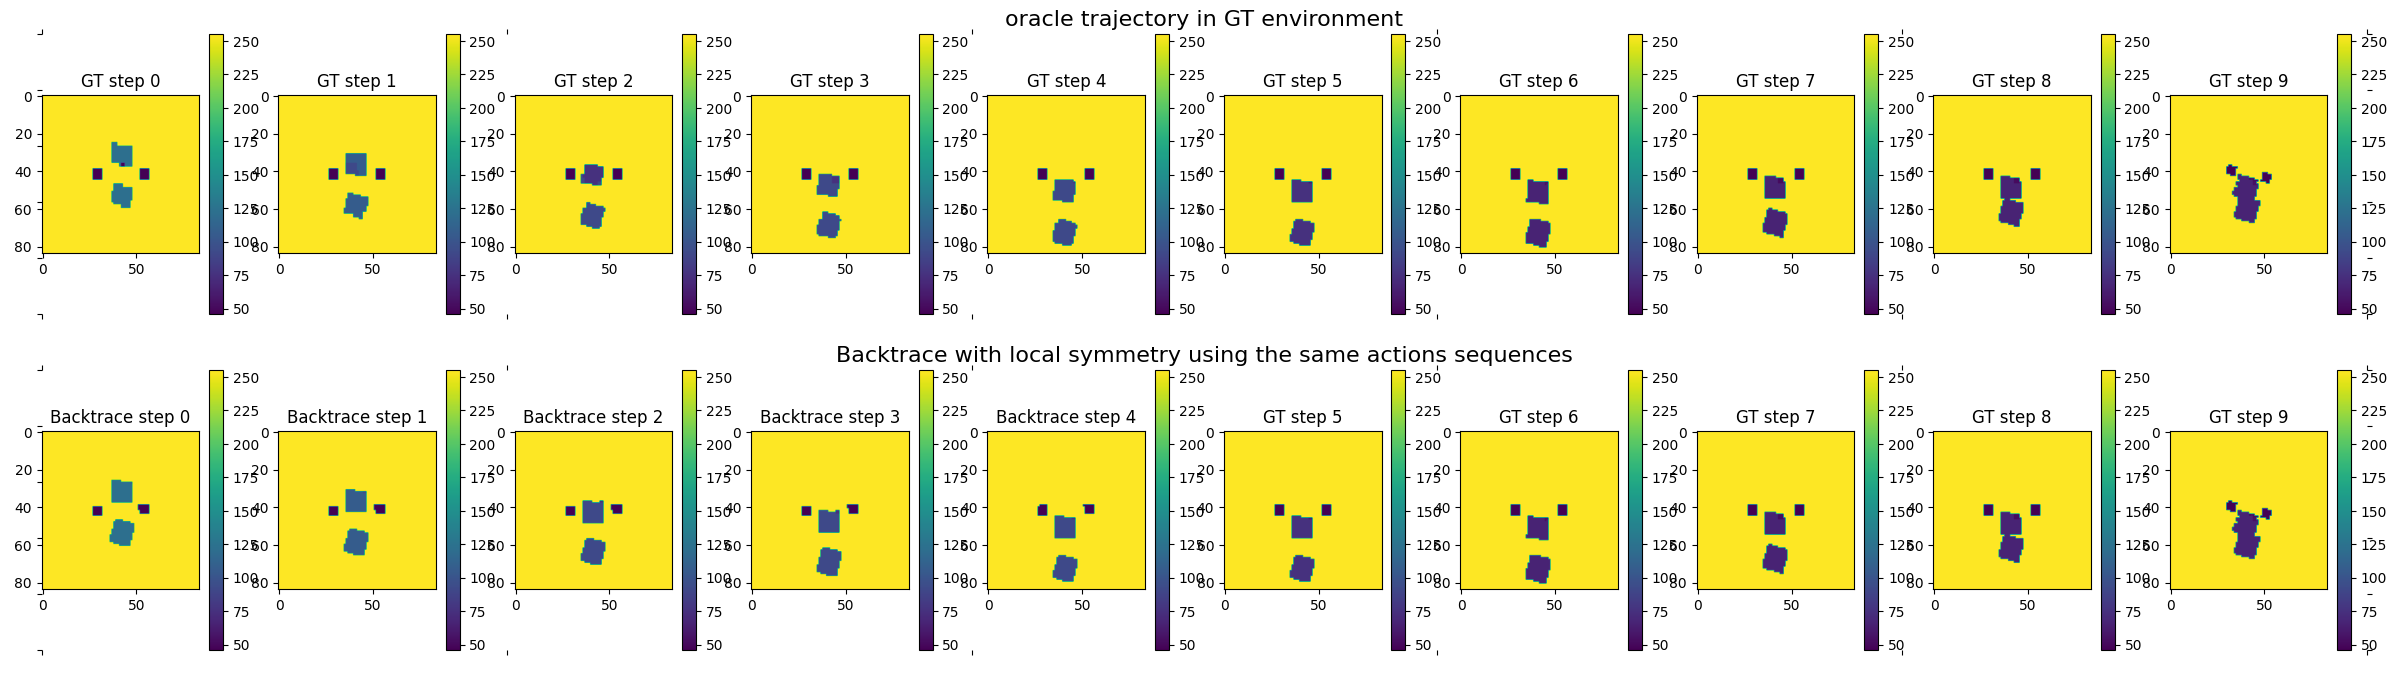

In [34]:
imgss = []
imgss.append([{"image": v, "title": f"GT step {i}"} for i, v in enumerate(origin_depth_image_traj)])
imgss.append([{"image": v, "title": f"GT step {i}" if i>=sym_step_idx else f"Backtrace step {i}"} for i, v in enumerate(sym_depth_image_traj)])
plt.rcParams['figure.figsize'] = [30, 8]
plot_img(imgss, big_axes_title=["oracle trajectory in GT environment", "Backtrace with local symmetry using the same actions sequences",])

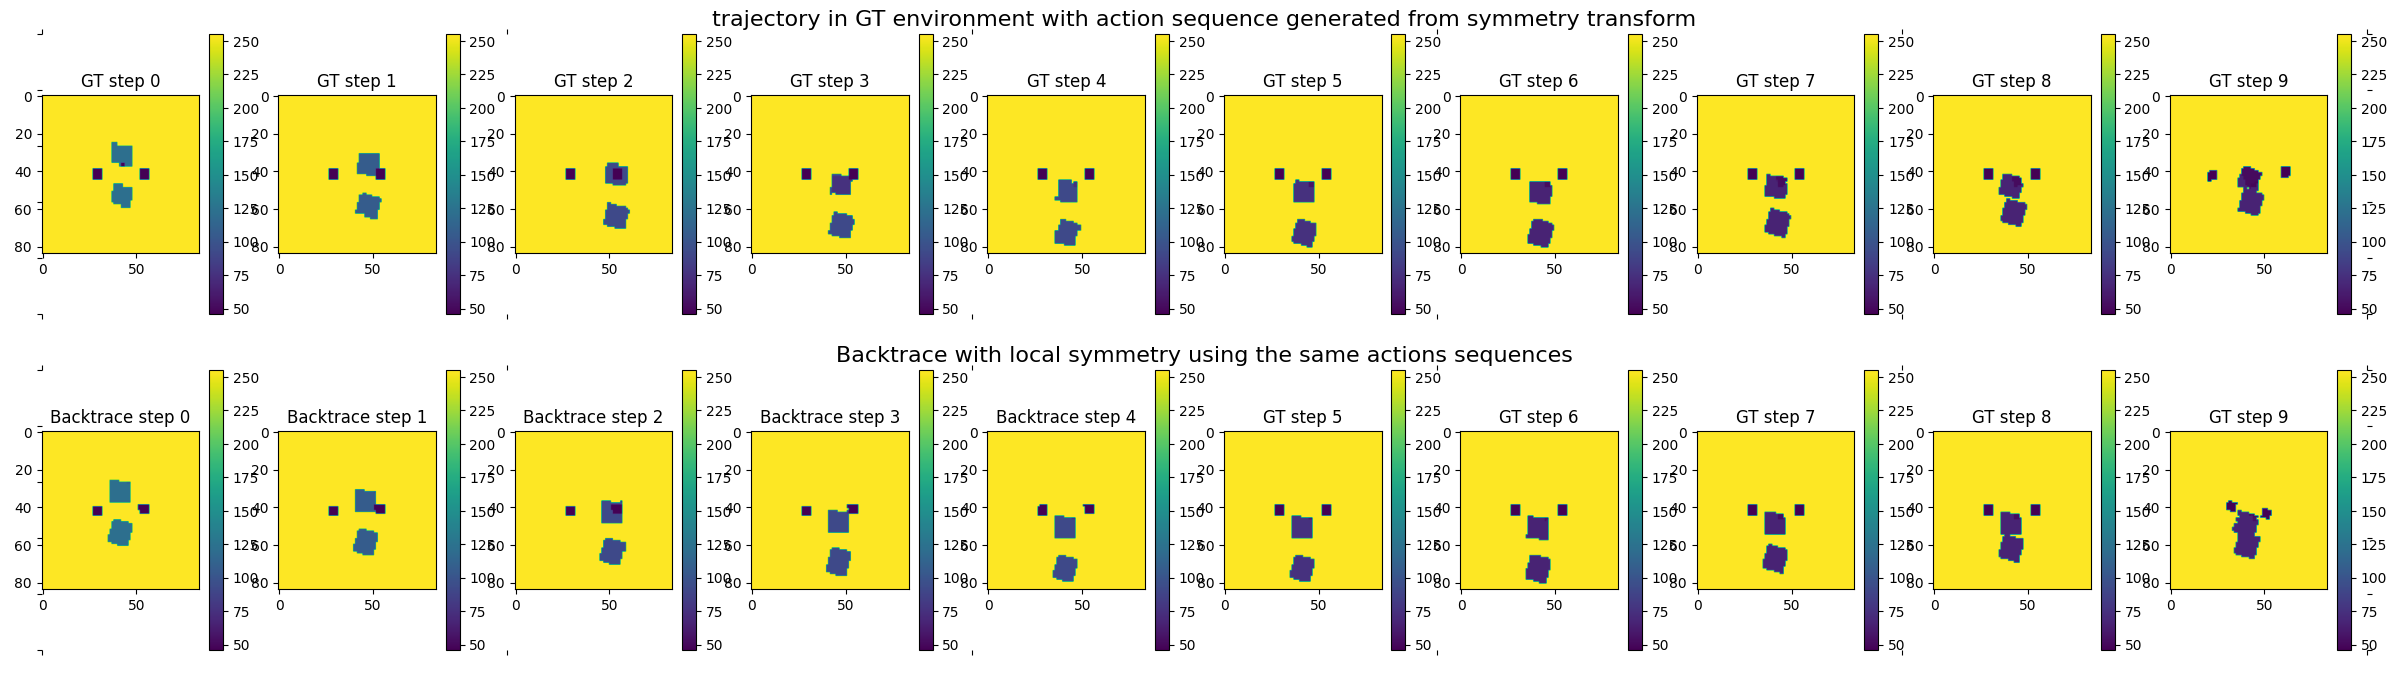

In [36]:
imgss = []
imgss.append([{"image": v, "title": f"GT step {i}"} for i, v in enumerate(gt_env_traj_with_sym_actions)])
imgss.append([{"image": v, "title": f"GT step {i}" if i>=sym_step_idx else f"Backtrace step {i}"} for i, v in enumerate(sym_depth_image_traj2)])
plt.rcParams['figure.figsize'] = [30, 8]
plot_img(imgss, big_axes_title=["trajectory in GT environment with action sequence generated from symmetry transform", "Backtrace with local symmetry using the same actions sequences",])
